Map → do work in parallel on each item

Reduce → combine all results into one

In [1]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, List
from IPython.display import Image, display

In [ ]:

class State(TypedDict):
    docs: List[str]
    summaries: List[str]
    final_summary: str

In [3]:
def map_summarize(state):
    print("Running MAP step")

    summaries = []
    for doc in state["docs"]:
        summaries.append(f"Summary: {doc[:10]}...")

    return {"summaries": summaries}

In [4]:
def reduce_summaries(state):
    print("Running REDUCE step")

    combined = " | ".join(state["summaries"])

    return {"final_summary": combined}

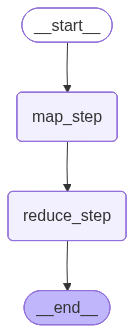

In [5]:
builder = StateGraph(State)

builder.add_node("map_step", map_summarize)
builder.add_node("reduce_step", reduce_summaries)

builder.set_entry_point("map_step")

builder.add_edge("map_step", "reduce_step")
builder.add_edge("reduce_step", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
result = graph.invoke({
    "docs": [
        "LangGraph is a framework for building agents",
        "It supports workflows and state machines",
        "It enables parallel execution and memory"
    ],
    "summaries": [],
    "final_summary": ""
})

print("\nFINAL OUTPUT:")
print(result["final_summary"])

Running MAP step
Running REDUCE step

FINAL OUTPUT:
Summary: LangGraph ... | Summary: It support... | Summary: It enables...
